In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
def quantize(data, n_bits):
    # 2 bits = 4 niveaux (00, 01, 10, 11)
    n_levels = 2**n_bits
    
    # Normaliser les données entre 0 et n_levels-1
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    normalized = (data - min_vals) / (max_vals - min_vals) * (n_levels-1)
    
    # Quantifier en valeurs entières de 0 à n_levels-1
    quantized = np.round(normalized).astype(int)
    quantized = np.clip(quantized, 0, n_levels-1)
    
    return quantized



def non_uniform_quantize(data, n_bits):
    n_levels = 2 ** n_bits
    
    # Calcul des quantiles pour les limites de chaque niveau
    quantiles = np.linspace(0, 1, n_levels + 1)
    thresholds = np.percentile(data, quantiles * 100)
    
    # Fonction de quantification : on affecte à chaque valeur de `data` un niveau
    quantized_data = np.digitize(data, thresholds[1:], right=True)
    
    return quantized_data


def export_data(data, filename):
    df = pd.DataFrame(data)
    df.to_csv(filename, header=False, index=False)
    print(f"Données exportées dans {filename}")

def process_dataset_from_sklearn(dataset_name, n_bits):
    if dataset_name == "iris":
        data = load_iris()
        output_file = f"data/iris_uni_{n_bits}bits.csv"
    elif dataset_name == "wine":
        data = load_wine() 
        output_file = f"data/wine_uni_{n_bits}bits.csv"
    else:
        raise ValueError("Dataset must be 'iris' or 'wine'")
    
    print(f"Dataset : {dataset_name}")
    print(f"Number of samples: {data.data.shape[0]}")
    print(f"Number of features: {data.data.shape[1]}")
    print(f"Number of classes: {len(np.unique(data.target))}")
    print("---")
    
    X = data.data
    X_quantized = quantize(X, n_bits)
    
    # Combine features and target into one array before exporting
    full_data = np.column_stack((X_quantized, data.target))
    export_data(full_data, output_file)


def non_uniform_process_dataset_from_sklearn(dataset_name, n_bits):
    if dataset_name == "iris":
        data = load_iris()
        output_file = f"data/iris_non_uni_{n_bits}bits.csv"
    elif dataset_name == "wine":
        data = load_wine() 
        output_file = f"data/wine_non_uni_{n_bits}bits.csv"
    else:
        raise ValueError("Dataset must be 'iris' or 'wine'")
    
    print(f"Dataset : {dataset_name}")
    print(f"Number of samples: {data.data.shape[0]}")
    print(f"Number of features: {data.data.shape[1]}")
    print(f"Number of classes: {len(np.unique(data.target))}")
    print("---")
    
    X = data.data
    X_quantized = non_uniform_quantize(X, n_bits)

    # print(X_quantized)
    # print(X_quantized.shape)
    
    # Combine features and target into one array before exporting
    full_data = np.column_stack((X_quantized, data.target))
    export_data(full_data, output_file)




# Friedman-diaconis


In [18]:
def friedman_diaconis_quantize(data, n_bits):
    n_levels = 2 ** n_bits
    n_samples = len(data)
    
    # Calculer la largeur des bins selon Friedman-Diaconis
    q75, q25 = np.percentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    bin_width = 2 * iqr * (n_samples ** (-1/3))
    
    # Créer les seuils pour chaque feature
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    
    # Ajuster le nombre de bins pour respecter n_levels
    n_bins = np.minimum(n_levels, np.ceil((max_vals - min_vals) / bin_width).astype(int))
    
    # Créer les seuils pour chaque feature
    thresholds = [np.linspace(min_vals[i], max_vals[i], n_bins[i]) 
                 for i in range(data.shape[1])]
    
    # Quantifier chaque feature
    quantized = np.zeros_like(data, dtype=int)
    for i in range(data.shape[1]):
        quantized[:, i] = np.digitize(data[:, i], thresholds[i][1:], right=True)
        # Normaliser pour avoir des valeurs entre 0 et n_levels-1
        quantized[:, i] = np.minimum(quantized[:, i], n_levels-1)
    
    return quantized


def fd_process_dataset_from_sklearn(dataset_name, n_bits):
    if dataset_name == "iris":
        data = load_iris()
        output_file = f"data/iris_fd_{n_bits}bits.csv"
    elif dataset_name == "wine":
        data = load_wine() 
        output_file = f"data/wine_fd_{n_bits}bits.csv"
    else:
        raise ValueError("Dataset must be 'iris' or 'wine'")
    
    print(f"Dataset : {dataset_name}")
    print(f"Number of samples: {data.data.shape[0]}")
    print(f"Number of features: {data.data.shape[1]}")
    print(f"Number of classes: {len(np.unique(data.target))}")
    print("---")
    
    X = data.data
    X_quantized = friedman_diaconis_quantize(X, n_bits)
    
    full_data = np.column_stack((X_quantized, data.target))
    export_data(full_data, output_file)

In [38]:
process_dataset_from_sklearn("iris", 5)

Dataset : iris
Number of samples: 150
Number of features: 4
Number of classes: 3
---
Données exportées dans data/iris_uni_5bits.csv


In [39]:

non_uniform_process_dataset_from_sklearn("iris", 5)

Dataset : iris
Number of samples: 150
Number of features: 4
Number of classes: 3
---
Données exportées dans data/iris_non_uni_5bits.csv


In [40]:
fd_process_dataset_from_sklearn("iris", 5)

Dataset : iris
Number of samples: 150
Number of features: 4
Number of classes: 3
---
Données exportées dans data/iris_fd_5bits.csv


In [22]:
import pandas as pd
def calculate_column_mean(csv_file, column_index):
    """
    Calculate mean of a specific column from a CSV file
    
    Args:
        csv_file (str): Path to the CSV file
        column_index (int): Index of the column to calculate mean for
        
    Returns:
        float: Mean value of the specified column
    """
    # Read CSV into DataFrame without headers
    df = pd.read_csv(csv_file, header=None)
    
    # Calculate mean of specified column
    column_mean = df[column_index].mean()
    
    return column_mean




In [23]:
# acc_wine_mean_4 = calculate_column_mean("logs/wine_4bits_4_64.csv", 0)
# print(f"Mean accuracy wine depth 4 : {acc_wine_mean_4}")
# acc_wine_mean_3 = calculate_column_mean("logs/wine_4bits_3_64.csv", 0)
# print(f"Mean accuracy wine depth 3 : {acc_wine_mean_3}")
# acc_wine_mean_2 = calculate_column_mean("logs/wine_4bits_2_64.csv", 0)
# print(f"Mean accuracy wine depth 2 : {acc_wine_mean_2}")
# # acc_wine_mean_1 = calculate_column_mean("logs/wine_4bits_1_64.csv", 0)
# # print(f"Mean accuracy wine depth 1 : {acc_wine_mean_1}")
# time_wine_mean_4 = calculate_column_mean("logs/wine_4bits_4_64.csv", 1)
# print(f"Mean time wine depth 4: {time_wine_mean_4}")
# time_wine_mean_3 = calculate_column_mean("logs/wine_4bits_3_64.csv", 1)
# print(f"Mean time wine depth 3 : {time_wine_mean_3}")
# time_wine_mean_2 = calculate_column_mean("logs/wine_4bits_2_64.csv", 1)
# print(f"Mean time wine depth 2 : {time_wine_mean_2}")
# # acc_wine_mean_1 = calculate_column_mean("logs/wine_4bits_1_64.csv", 0)
# # print(f"Mean accuracy wine depth 1 : {acc_wine_mean_1}")

In [ ]:
acc_iris_mean_4 = calculate_column_mean("logs/iris_4bits_4_64.csv", 0)
print(f"Mean accuracy iris depth 4 : {acc_iris_mean_4}")
acc_iris_mean_3 = calculate_column_mean("logs/iris_4bits_3_64.csv", 0)
print(f"Mean accuracy iris depth 3 : {acc_iris_mean_3}")
# acc_iris_mean_2 = calculate_column_mean("logs/iris_4bits_2_64.csv", 0)
# print(f"Mean accuracy iris depth 2 : {acc_iris_mean_2}")
# acc_iris_mean_1 = calculate_column_mean("logs/iris_4bits_1_64.csv", 0)
# print(f"Mean accuracy iris depth 1 : {acc_iris_mean_1}")
time_iris_mean_4 = calculate_column_mean("logs/iris_4bits_4_64.csv", 1)
print(f"Mean time iris depth 4: {time_iris_mean_4}")
time_iris_mean_3 = calculate_column_mean("logs/iris_4bits_3_64.csv", 1)
print(f"Mean time iris depth 3 : {time_iris_mean_3}")
# time_iris_mean_2 = calculate_column_mean("logs/iris_4bits_2_64.csv", 1)
# print(f"Mean time iris depth 2 : {time_iris_mean_2}")
# acc_iris_mean_1 = calculate_column_mean("logs/iris_4bits_1_64.csv", 0)
# print(f"Mean accuracy iris depth 1 : {acc_iris_mean_1}")

/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_43403/582839107.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "^-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(depth[2:], accuracy_private_wine[2:], '^-', label="Accuracy PrivateDTs", color='black', linestyle="--")
/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_43403/582839107.py:45: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "^-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(depth[2:], accuracy_private_iris[2:], '^-', label="Accuracy PrivateDTs", color='black', linestyle="--")


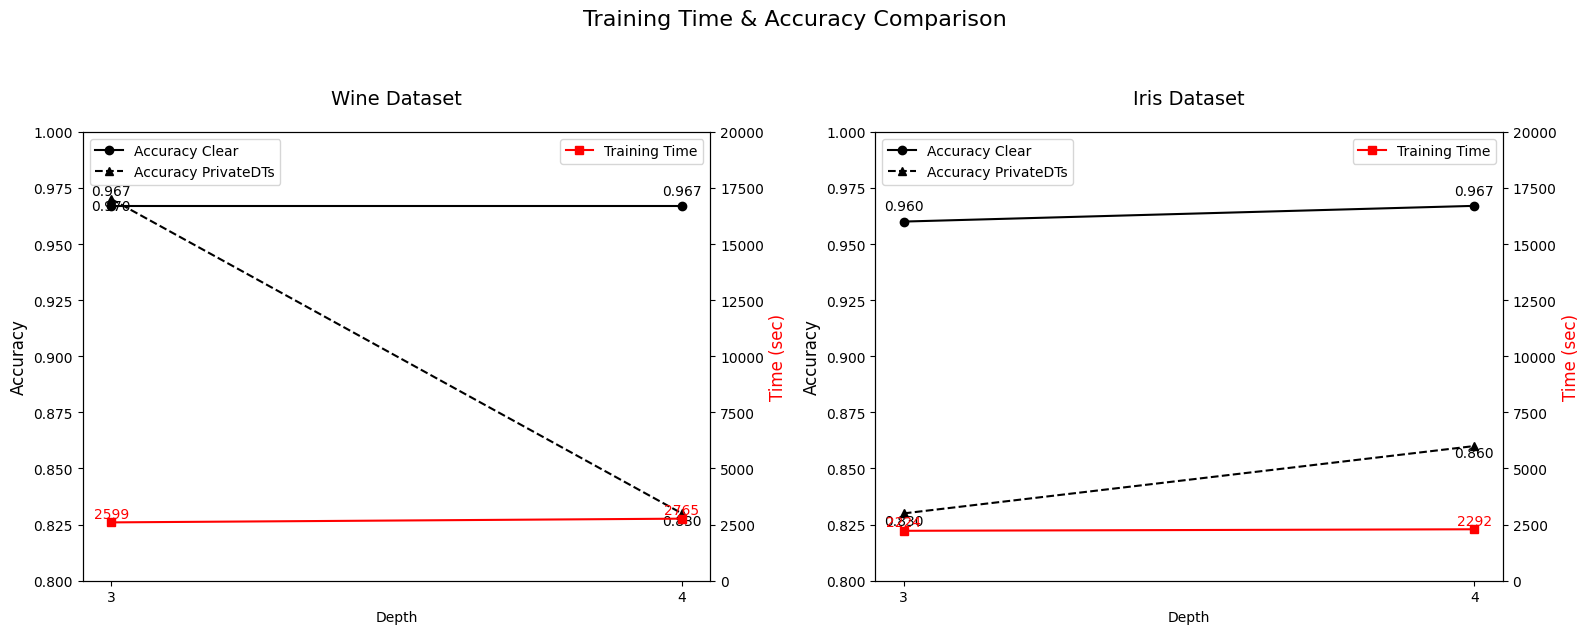

In [127]:
import matplotlib.pyplot as plt

# Données pour reproduire le graphique
depth = [1, 2, 3, 4]  # Profondeur
accuracy_clear_wine = [None, None, 0.967, 0.967]
accuracy_private_wine = [None, None, 0.97, 0.83]
training_time_wine = [None, None, 2599, 2765]

accuracy_clear_iris = [None, None, 0.960, 0.967]
accuracy_private_iris = [None, None, 0.83, 0.86]
training_time_iris = [None, None, 2224, 2292]

# Créer deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Premier graphique pour Wine
ax1_twin = ax1.twinx()
ax1.set_xlabel("Depth")
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_ylim(0.8, 1.0)
ax1.set_xticks(depth)
ax1.plot(depth[2:], accuracy_clear_wine[2:], 'o-', label="Accuracy Clear", color='black')
ax1.plot(depth[2:], accuracy_private_wine[2:], '^-', label="Accuracy PrivateDTs", color='black', linestyle="--")

# Ajouter les valeurs sur les points pour Wine
for i in range(2, len(depth)):
    ax1.text(depth[i], accuracy_clear_wine[i] + 0.005, f"{accuracy_clear_wine[i]:.3f}", ha='center')
    ax1.text(depth[i], accuracy_private_wine[i] - 0.005, f"{accuracy_private_wine[i]:.3f}", ha='center')

ax1_twin.set_ylabel("Time (sec)", fontsize=12, color="red")
ax1_twin.set_ylim(0, 20000)
ax1_twin.plot(depth[2:], training_time_wine[2:], 's-', color='red', label="Training Time")

# Ajouter les valeurs pour les temps (Wine)
for i in range(2, len(depth)):
    ax1_twin.text(depth[i], training_time_wine[i] + 200, f"{training_time_wine[i]}", color="red", ha='center')

# Deuxième graphique pour Iris
ax2_twin = ax2.twinx()
ax2.set_xlabel("Depth")
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_ylim(0.8, 1.0)
ax2.set_xticks(depth)
ax2.plot(depth[2:], accuracy_clear_iris[2:], 'o-', label="Accuracy Clear", color='black')
ax2.plot(depth[2:], accuracy_private_iris[2:], '^-', label="Accuracy PrivateDTs", color='black', linestyle="--")

# Ajouter les valeurs sur les points pour Iris
for i in range(2, len(depth)):
    ax2.text(depth[i], accuracy_clear_iris[i] + 0.005, f"{accuracy_clear_iris[i]:.3f}", ha='center')
    ax2.text(depth[i], accuracy_private_iris[i] - 0.005, f"{accuracy_private_iris[i]:.3f}", ha='center')

ax2_twin.set_ylabel("Time (sec)", fontsize=12, color="red")
ax2_twin.set_ylim(0, 20000)
ax2_twin.plot(depth[2:], training_time_iris[2:], 's-', color='red', label="Training Time")

# Ajouter les valeurs pour les temps (Iris)
for i in range(2, len(depth)):
    ax2_twin.text(depth[i], training_time_iris[i] + 200, f"{training_time_iris[i]}", color="red", ha='center')

# Titres et légendes
ax1.set_title("Wine Dataset", fontsize=14, pad=20)
ax2.set_title("Iris Dataset", fontsize=14, pad=20)

ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")
ax2.legend(loc="upper left")
ax2_twin.legend(loc="upper right")

fig.suptitle("Training Time & Accuracy Comparison", fontsize=16, y=1.05)
plt.tight_layout()


plt.show()

# Quantization impact on Extra-Trees

/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/3972649846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/3972649846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/3972649846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)


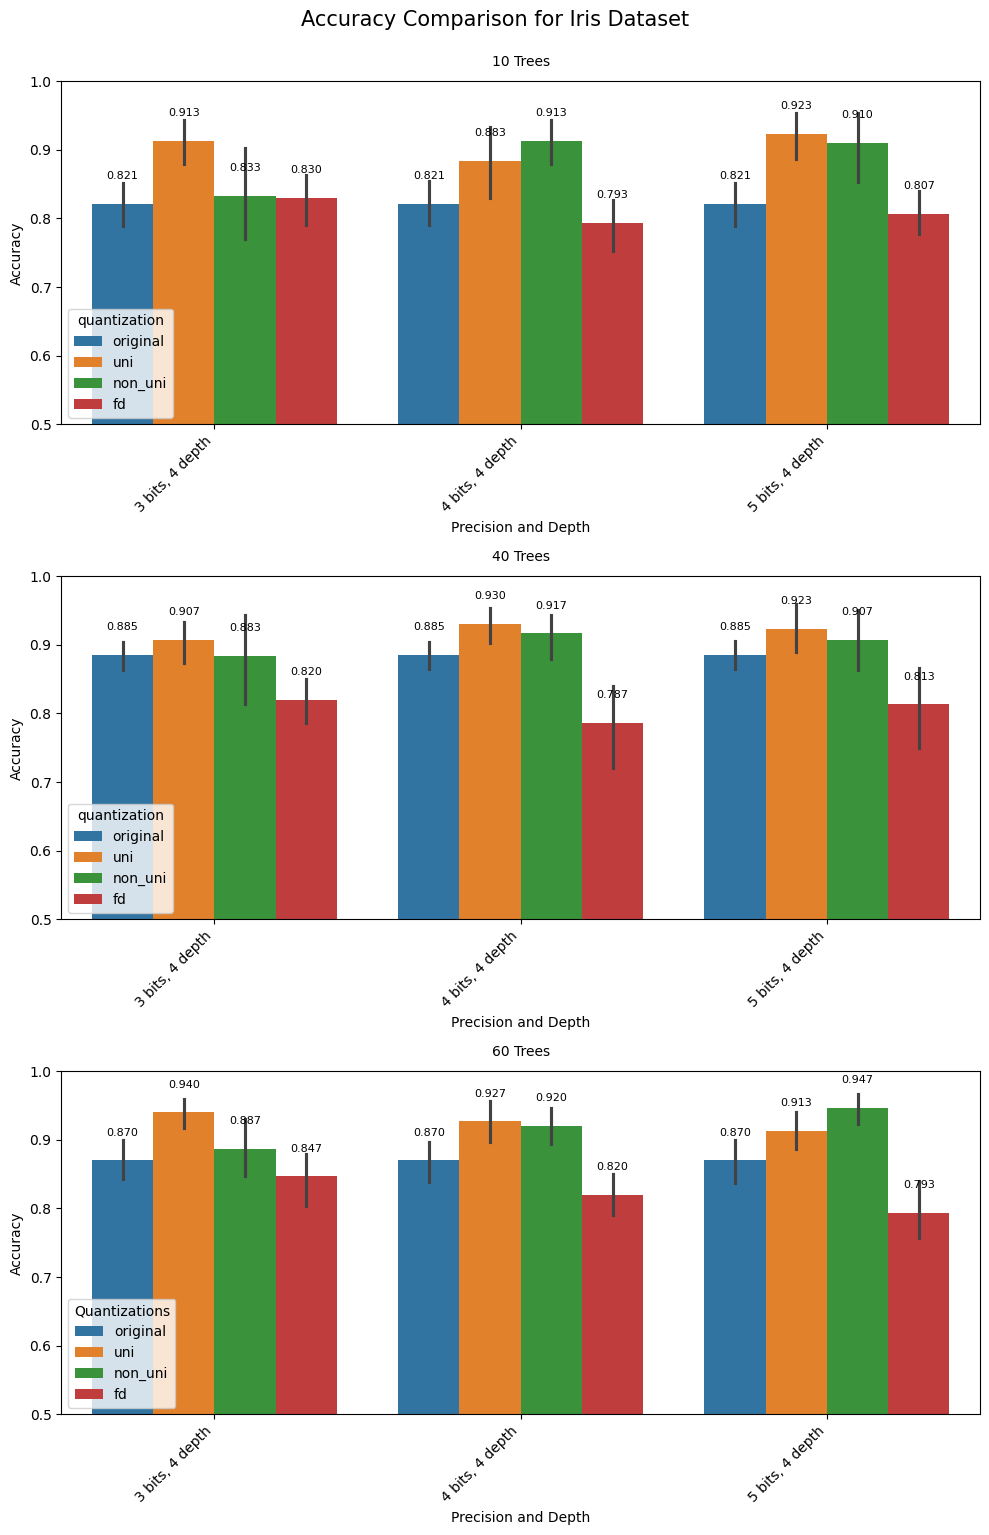

In [ ]:
import pandas as pd
import seaborn as sns

def plot_accuracy_vs_all_params(data, dataset_name):
    fig = plt.figure(figsize=(10, 15))

    for i, n_forests in enumerate(num_forests):
        ax = fig.add_subplot(3, 1, i+1)
        sns.barplot(x="precision_depth", y="accuracy", hue="quantization", data=data[data["num_forests"] == n_forests], ax=ax) 
        ax.set_ylim(0.5, 1)# Rotate x-axis labels for better readability
        # add a subtitle for each plot
        ax.set_title(f"{n_forests} Trees", fontsize=10, y=1.02)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
        ax.set_xlabel("Precision and Depth")
        ax.set_ylabel("Accuracy")
        # add the text on top of each bar
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="center", xytext=(0, 20), textcoords='offset points', fontsize=8)

    plt.tight_layout()

    fig.suptitle(f"Accuracy Comparison for {dataset_name.capitalize()} Dataset", fontsize=15, y=1.02)
    plt.legend(title="Quantizations")
    plt.show()


dataset_name = "iris"
precisions = [3, 4, 5]
num_forests = [10, 40, 60]
quantizations = ["original","uni", "non_uni", "fd"]
depths = [4]

data = pd.DataFrame(columns=["precision", "num_forests", "quantizations", "depth"])

for n_bits in precisions:
    for n_forests in num_forests:
        for quantization in quantizations:
            for depth in depths:
                if quantization == "original":
                    filename = f"logs/{dataset_name}_{depth}d_{n_forests}m_clear.csv"
                else:
                    filename = f"logs/{dataset_name}_{quantization}_{n_bits}bits_{depth}d_{n_forests}m_clear.csv"
                result = pd.read_csv(filename, header=None, names=["accuracy", "training_time", "inference_time"])
                result["precision"] = n_bits
                result["num_forests"] = n_forests
                result["quantization"] = quantization
                result["depth"] = depth
                data = pd.concat([data, result])

data["precision_depth"] = data["precision"].astype(str) + " bits, " + data["depth"].astype(str) + " depth"


plot_accuracy_vs_all_params(data, dataset_name)



## Quantization impact on Random Forests

/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/2540922146.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([[quantization, n_bits, n_forests, depth, accuracy]], columns=results.columns)])
/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/3972649846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
/var/folders/zf/mm8hyjbs5kdg2gxhblkfwn0c0000gn/T/ipykernel_9616/3972649846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

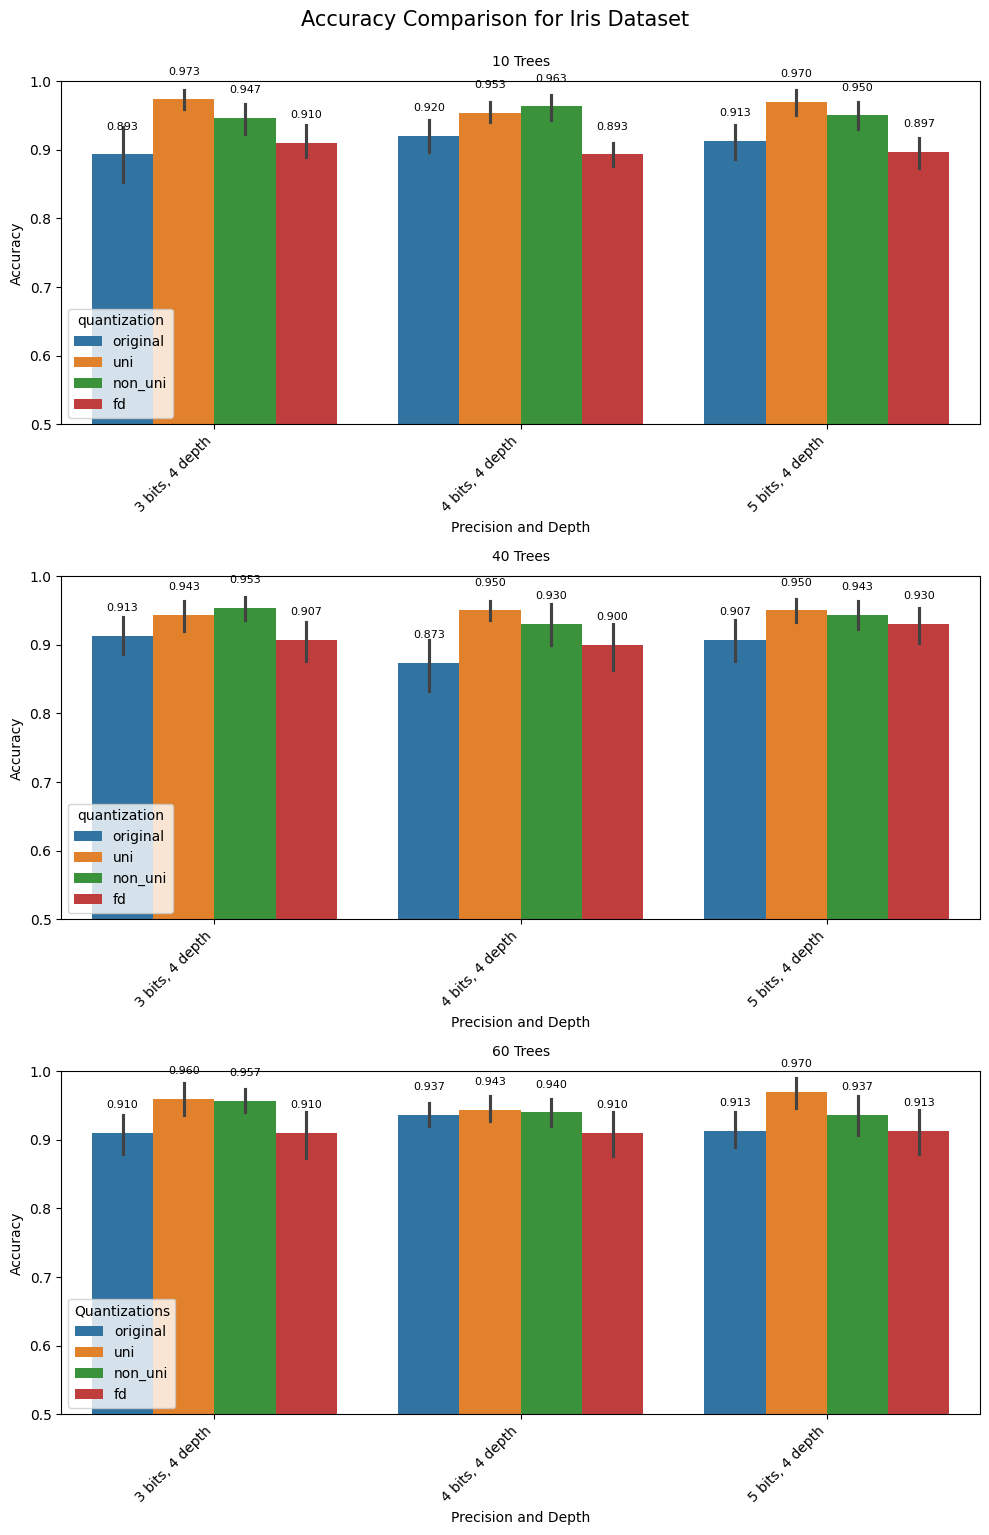

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

num_experiments = 10

results = pd.DataFrame(columns=["quantization", "precision", "num_forests", "depth", "accuracy"])

for quantization in quantizations:
    if quantization == "original":
        dataset_name = "iris"
    else:
        filename = f"data/{dataset_name}_{quantization}_{n_bits}bits.csv"
    data = pd.read_csv(filename, header=None)
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    for n_bits in precisions:
        for n_forests in num_forests:
            for depth in depths:
                accuracies = []
                for expe in range(num_experiments):
                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
                    clf = RandomForestClassifier(n_estimators=n_forests, max_depth=depth)
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    accuracy = accuracy_score(y_test, y_pred)
                    accuracies.append(accuracy)
                    results = pd.concat([results, pd.DataFrame([[quantization, n_bits, n_forests, depth, accuracy]], columns=results.columns)])


results["precision_depth"] = results["precision"].astype(str) + " bits, " + results["depth"].astype(str) + " depth"

plot_accuracy_vs_all_params(results, dataset_name)

# results 


# ANALYSE GINI ACCURACY 

In [3]:
import re
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def plot_accuracy_gini_accumulate_runs(acc_d0_list, acc_d1_list, dataset_name, runs=None, k=None,d=None):
    """
    Crée un barplot groupé pour visualiser l'évolution de l'accuracy sur 10 runs (Gini + accumulation)
    sur le dataset donné.

    Args:
        acc_d0_list (list of float): Liste des accuracies après D_0 (gini based).
        acc_d1_list (list of float): Liste des accuracies après D_0 (gini based) + D_1.
        dataset_name (str): Nom du dataset à afficher dans le titre et le nom du fichier png.
        runs (list or None): Liste d'indices de runs à afficher sur l'axe x (optionnel).
    """

    n_runs = len(acc_d0_list)
    if runs is None:
        runs = list(range(1, n_runs + 1))
    width = 0.4
    x = range(n_runs)

    plt.figure(figsize=(8, 4))

    plt.bar(
        [i - width / 2 for i in x],
        acc_d0_list,
        width=width,
        label="Accuracy après D_0 (gini based)",
    )
    plt.bar(
        [i + width / 2 for i in x],
        acc_d1_list,
        width=width,
        label="Accuracy après D_0 (gini based)+ D_1",
    )

    plt.xticks(x, [f"Run {i}" for i in runs], rotation=45)
    plt.ylim(0.0, 1.0)
    plt.ylabel("Accuracy")
    plt.title(
        f"Évolution de l'accuracy sur {n_runs} runs (Gini + accumulation) sur le dataset {dataset_name} avec k={k} et d={d}"
    )
    plt.tight_layout()
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    # if depth is not None:
    #     plt.savefig(
    #         f"accuracy_gini_accumulate_runs_{dataset_name}_d{depth}.png",
    #         dpi=300,
    #         bbox_inches="tight",
    #     )
    # else:
    #     plt.savefig(
    #         f"accuracy_gini_accumulate_runs_{dataset_name}.png",
    #         dpi=300,
    #         bbox_inches="tight",
    #     )
    plt.show()


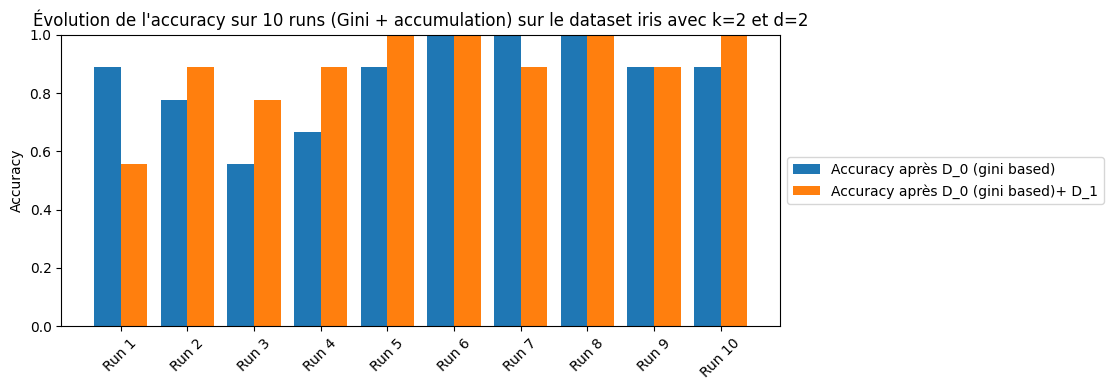

Moyenne des accuracies après D_0 (gini based): 0.8556
Moyenne des accuracies après D_0 + D_1: 0.8889


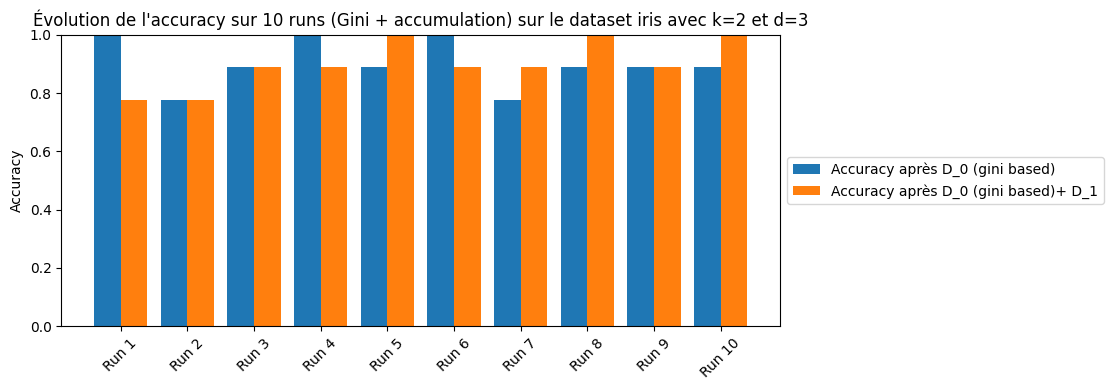

Moyenne des accuracies après D_0 (gini based): 0.9000
Moyenne des accuracies après D_0 + D_1: 0.9000


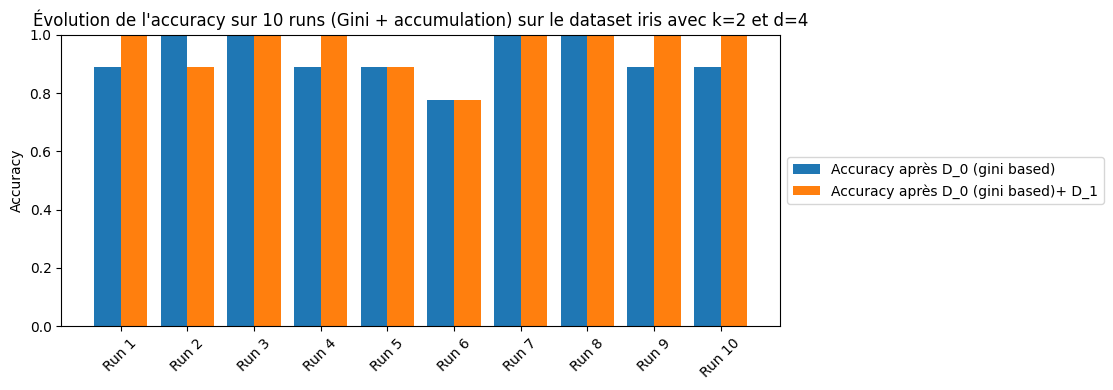

Moyenne des accuracies après D_0 (gini based): 0.9222
Moyenne des accuracies après D_0 + D_1: 0.9556


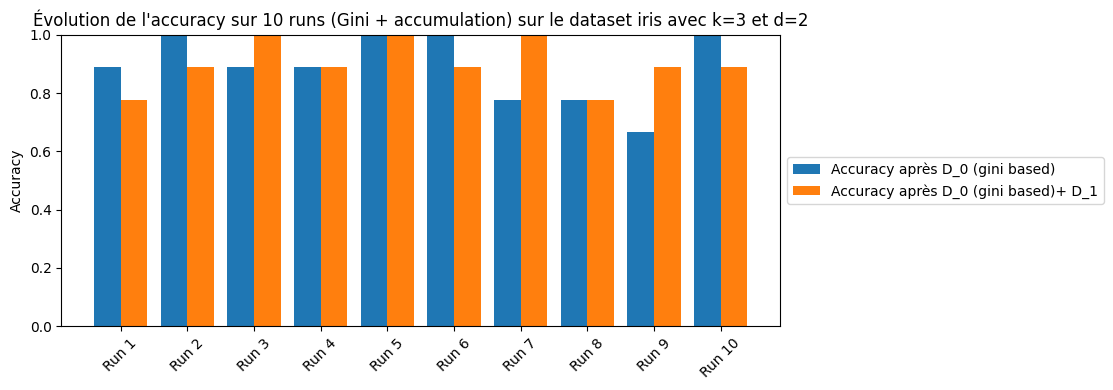

Moyenne des accuracies après D_0 (gini based): 0.8889
Moyenne des accuracies après D_0 + D_1: 0.9000


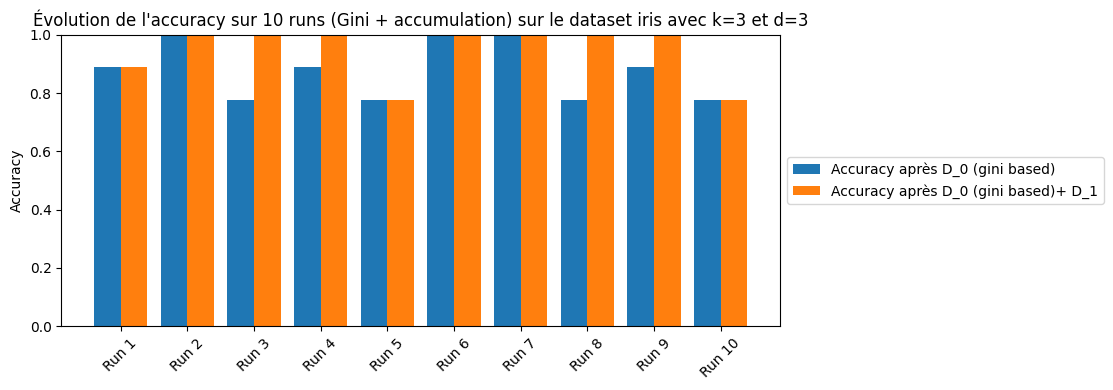

Moyenne des accuracies après D_0 (gini based): 0.8778
Moyenne des accuracies après D_0 + D_1: 0.9444


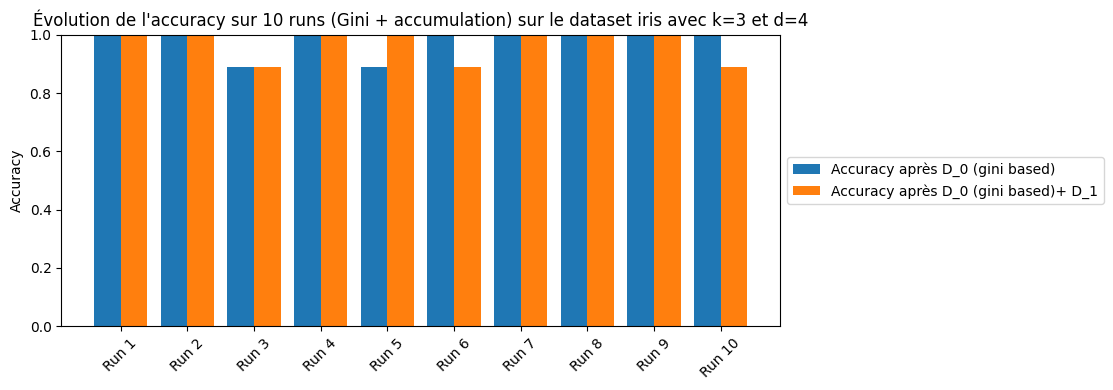

Moyenne des accuracies après D_0 (gini based): 0.9778
Moyenne des accuracies après D_0 + D_1: 0.9667


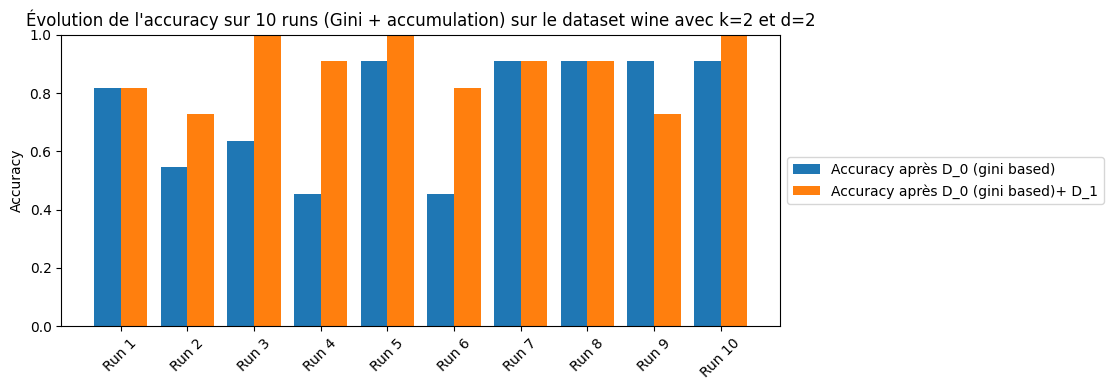

Moyenne des accuracies après D_0 (gini based): 0.7455
Moyenne des accuracies après D_0 + D_1: 0.8818


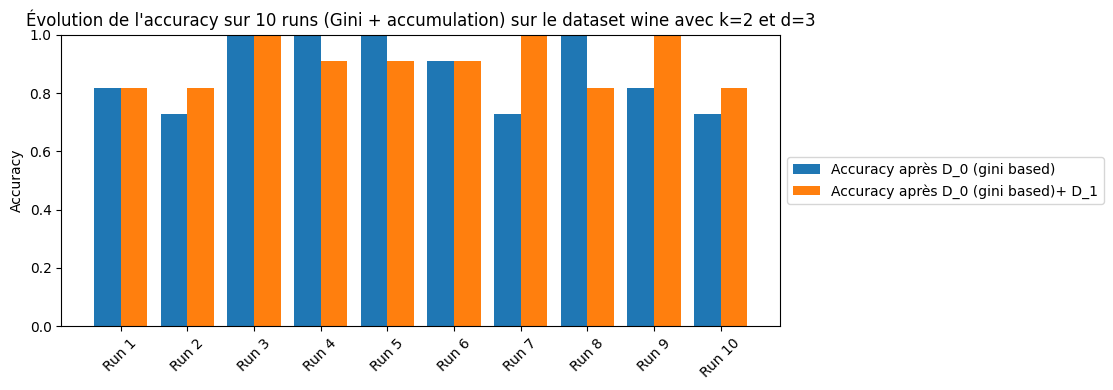

Moyenne des accuracies après D_0 (gini based): 0.8727
Moyenne des accuracies après D_0 + D_1: 0.9000


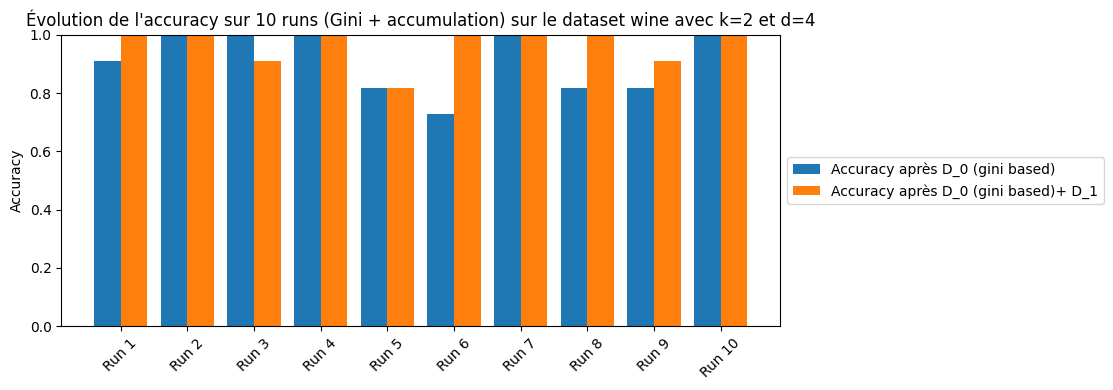

Moyenne des accuracies après D_0 (gini based): 0.9091
Moyenne des accuracies après D_0 + D_1: 0.9636


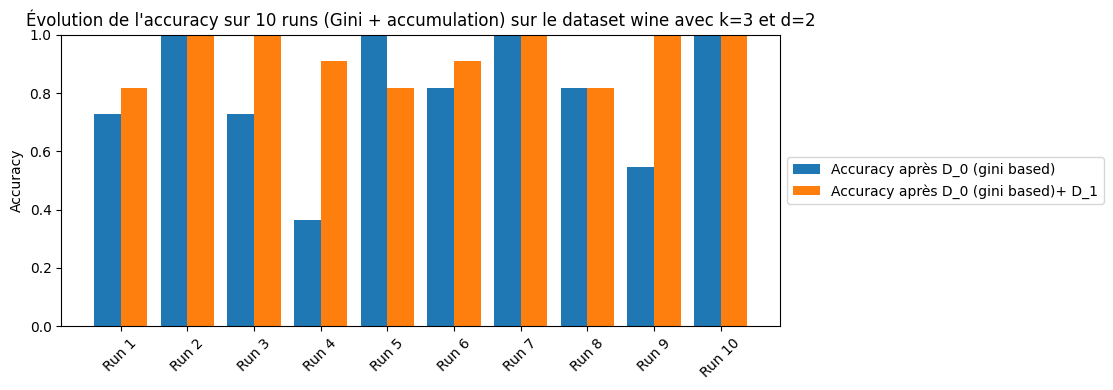

Moyenne des accuracies après D_0 (gini based): 0.8000
Moyenne des accuracies après D_0 + D_1: 0.9273


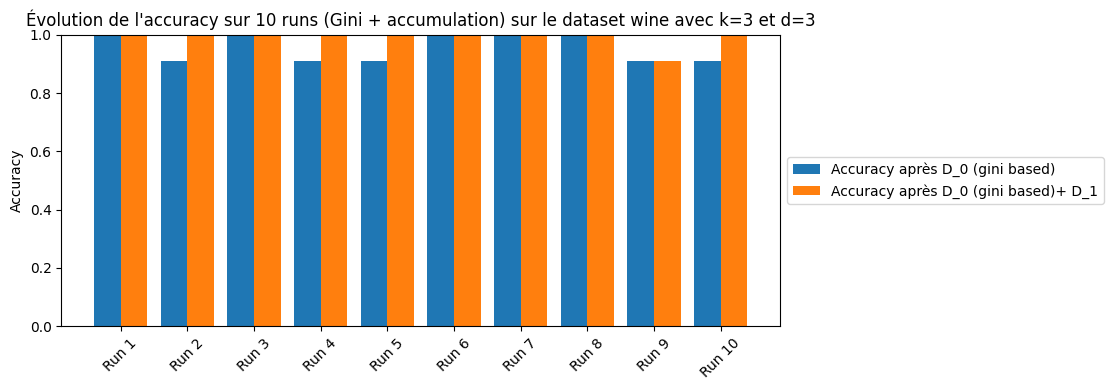

Moyenne des accuracies après D_0 (gini based): 0.9545
Moyenne des accuracies après D_0 + D_1: 0.9909


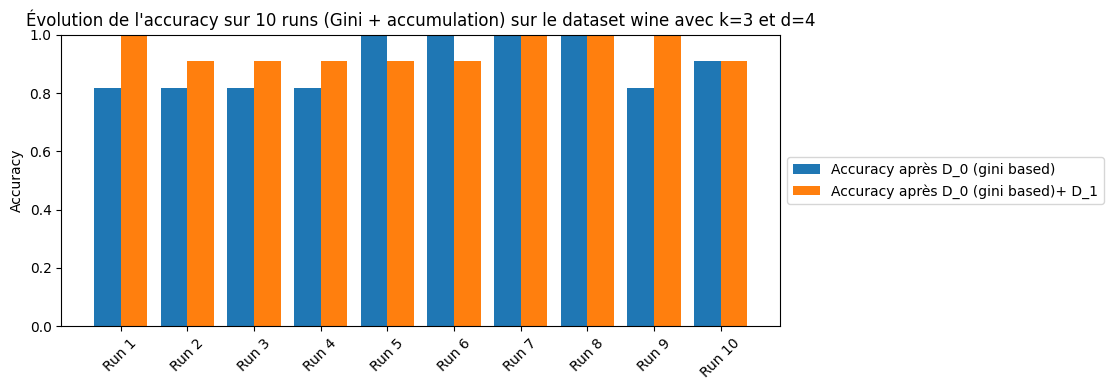

Moyenne des accuracies après D_0 (gini based): 0.9000
Moyenne des accuracies après D_0 + D_1: 0.9455


In [9]:

for dataset_name in ["iris", "wine"]:
    for k in [2, 3]:
        for d in [2,3,4]:
            log_path = f"/Users/sofianeazogagh/Desktop/PROBONITE/src/comp_free/clean/k={k}/d={d}/results_gini_{dataset_name}_k{k}_d{d}.txt"

            with open(log_path, "r") as f:
                log = f.read()

            # On récupère toutes les accuracies
            acc_d0_list = [float(x) for x in re.findall(r"Accuracy on d_0:\s*([0-9.]+)", log)]
            acc_d1_list = [float(x) for x in re.findall(r"Accuracy on d_1:\s*([0-9.]+)", log)]

            if len(acc_d0_list) == 0 or len(acc_d0_list) != len(acc_d1_list):
                raise RuntimeError(
                    f"Problème de parsing: {len(acc_d0_list)} valeurs d0, {len(acc_d1_list)} valeurs d1."
                )

            plot_accuracy_gini_accumulate_runs(acc_d0_list, acc_d1_list, dataset_name,None, k, d)

            print(f"Moyenne des accuracies après D_0 (gini based): {sum(acc_d0_list)/len(acc_d0_list):.4f}")
            print(f"Moyenne des accuracies après D_0 + D_1: {sum(acc_d1_list)/len(acc_d1_list):.4f}")
        




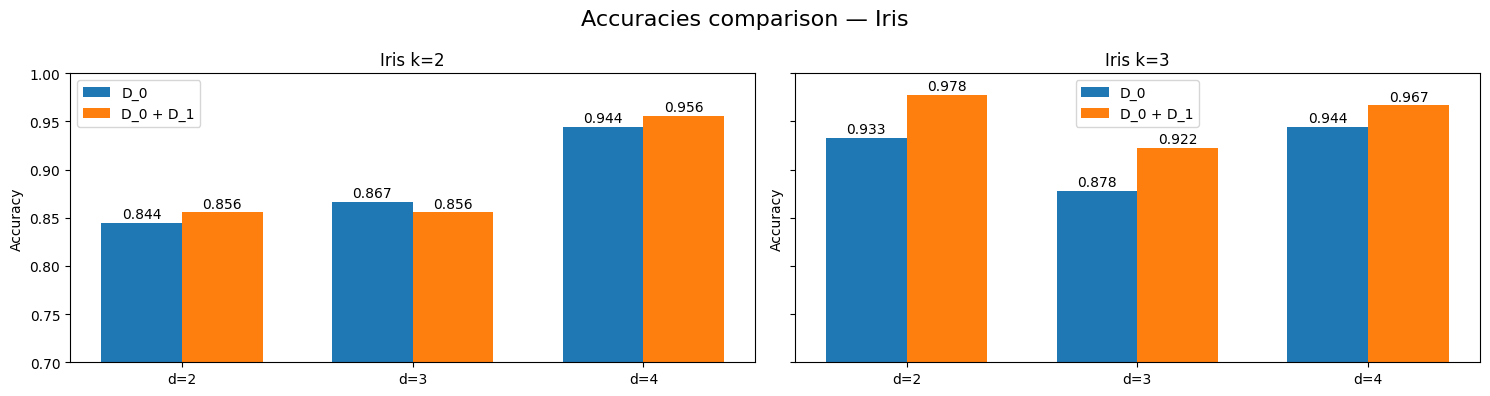

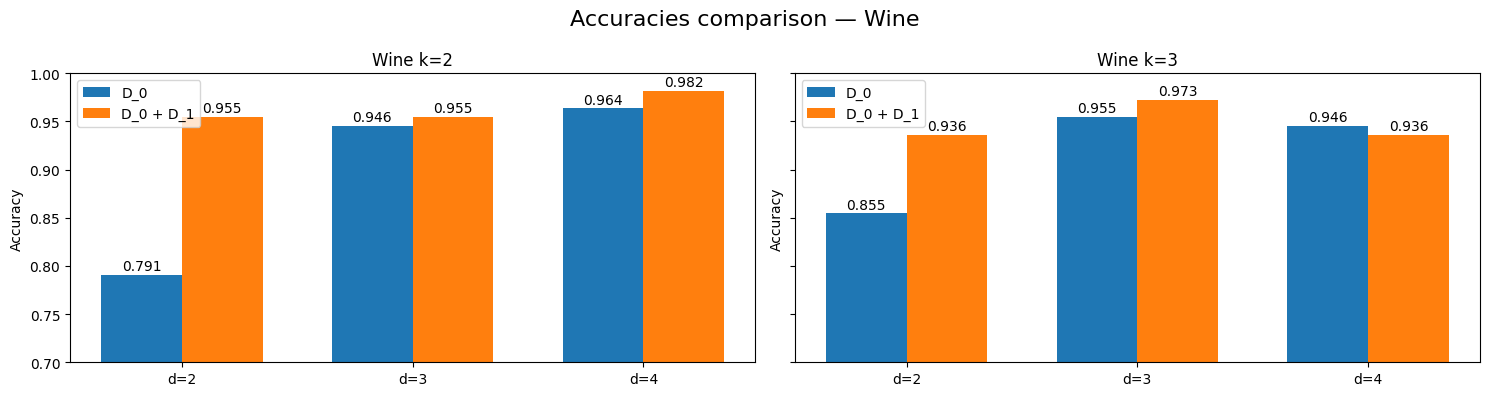

In [ ]:

# -----------------------------
# Données fournies
# -----------------------------

data = {
    "Iris k=2": {
        2: (0.8444, 0.8556),
        3: (0.8667, 0.8556),
        4: (0.9444, 0.9556),
    },
    "Iris k=3": {
        2: (0.9333, 0.9778),
        3: (0.8778, 0.9222),
        4: (0.9444, 0.9667),
    },
    "Wine k=2": {
        2: (0.7909, 0.9545),
        3: (0.9455, 0.9545),
        4: (0.9636, 0.9818),
    },
    "Wine k=3": {
        2: (0.8545, 0.9364),
        3: (0.9545, 0.9727),
        4: (0.9455, 0.9364),
    }
}

# -----------------------------
# Plotting
# -----------------------------

for dataset in ["Iris", "Wine"]:
    # On filtre les clés correspondantes
    subset = {k: v for k, v in data.items() if k.startswith(dataset)}
    
    fig, axes = plt.subplots(1, len(subset), figsize=(15, 4), sharey=True)
    fig.suptitle(f"Accuracies comparison — {dataset}", fontsize=16)

    if len(subset) == 1:
        axes = [axes]  # S'il n'y a qu'un seul subplot

    for ax, (title, values) in zip(axes, subset.items()):
        depths = sorted(values.keys())
        acc_d0 = [values[d][0] for d in depths]
        acc_d1 = [values[d][1] for d in depths]

        x = np.arange(len(depths))
        width = 0.35

        ax.bar(x - width/2, acc_d0, width, label="D_0")
        ax.bar(x + width/2, acc_d1, width, label="D_0 + D_1")

        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([f"d={d}" for d in depths])
        ax.set_ylim(0.7, 1.0)
        ax.set_ylabel("Accuracy")

        # valeurs au-dessus
        for i, v in enumerate(acc_d0):
            ax.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center")

        for i, v in enumerate(acc_d1):
            ax.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center")

        ax.legend()

    plt.tight_layout()
    plt.show()

iris k=2 d=2 -> Moyenne après D_0: 0.8444, après D_0+D_1: 0.8556
iris k=2 d=3 -> Moyenne après D_0: 0.8667, après D_0+D_1: 0.8556
iris k=2 d=4 -> Moyenne après D_0: 0.9444, après D_0+D_1: 0.9556
iris k=3 d=2 -> Moyenne après D_0: 0.9333, après D_0+D_1: 0.9778
iris k=3 d=3 -> Moyenne après D_0: 0.8778, après D_0+D_1: 0.9222
iris k=3 d=4 -> Moyenne après D_0: 0.9444, après D_0+D_1: 0.9667
wine k=2 d=2 -> Moyenne après D_0: 0.7909, après D_0+D_1: 0.9545
wine k=2 d=3 -> Moyenne après D_0: 0.9455, après D_0+D_1: 0.9545
wine k=2 d=4 -> Moyenne après D_0: 0.9636, après D_0+D_1: 0.9818
wine k=3 d=2 -> Moyenne après D_0: 0.8545, après D_0+D_1: 0.9364
wine k=3 d=3 -> Moyenne après D_0: 0.9545, après D_0+D_1: 0.9727
wine k=3 d=4 -> Moyenne après D_0: 0.9455, après D_0+D_1: 0.9364


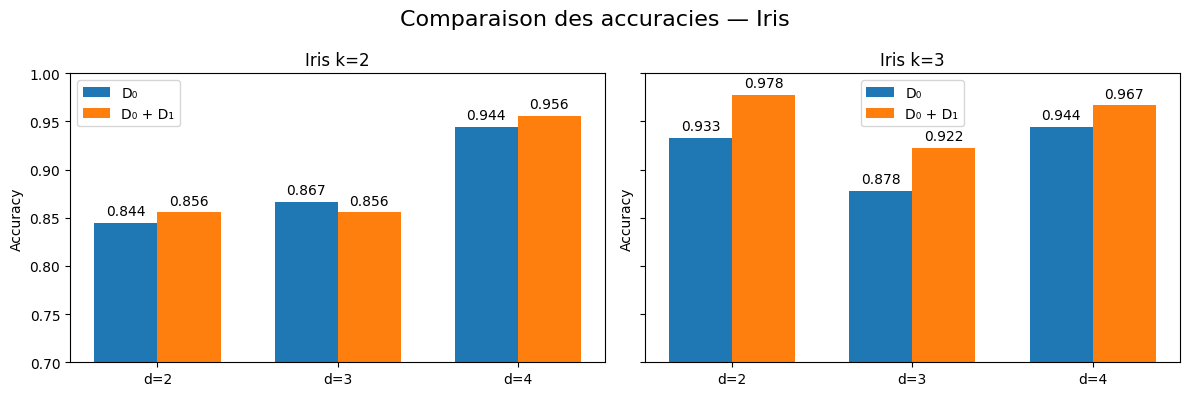

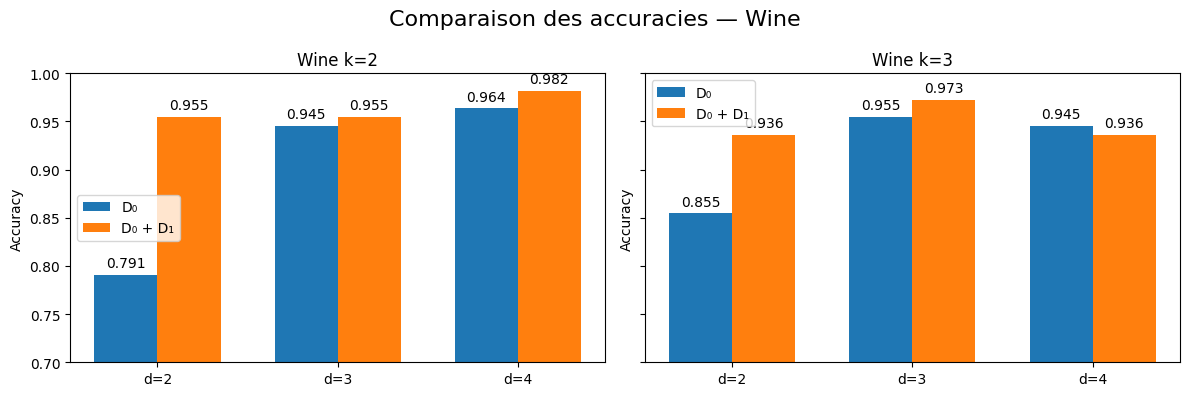

In [12]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt

base_dir = "/Users/sofianeazogagh/Desktop/PROBONITE/src/comp_free/no_clean"

datasets = ["iris", "wine"]
ks = [2, 3]
depths = [2, 3, 4]

# data[(dataset_name, k)][d] = (mean_d0, mean_d1)
data = {}

for dataset_name in datasets:
    for k in ks:
        key = (dataset_name, k)
        data[key] = {}
        for d in depths:
            log_path = os.path.join(
                base_dir,
                f"k={k}",
                f"d={d}",
                f"results_gini_{dataset_name}.txt",
            )

            if not os.path.isfile(log_path):
                print(f"[WARN] Fichier manquant : {log_path}")
                continue

            with open(log_path, "r") as f:
                log = f.read()

            acc_d0_list = [float(x) for x in re.findall(r"Accuracy on d_0:\s*([0-9.]+)", log)]
            acc_d1_list = [float(x) for x in re.findall(r"Accuracy on d_1:\s*([0-9.]+)", log)]

            if len(acc_d0_list) == 0 or len(acc_d0_list) != len(acc_d1_list):
                raise RuntimeError(
                    f"Problème de parsing pour {dataset_name}, k={k}, d={d} : "
                    f"{len(acc_d0_list)} valeurs d0, {len(acc_d1_list)} valeurs d1."
                )

            mean_d0 = sum(acc_d0_list) / len(acc_d0_list)
            mean_d1 = sum(acc_d1_list) / len(acc_d1_list)

            print(f"{dataset_name} k={k} d={d} -> "
                  f"Moyenne après D_0: {mean_d0:.4f}, après D_0+D_1: {mean_d1:.4f}")

            data[key][d] = (mean_d0, mean_d1)

# -----------------------------
# Plotting comme avant
# -----------------------------

for dataset_name in datasets:
    # on prépare les titres "Iris k=2", "Iris k=3", etc.
    subset_keys = [(dataset_name, k) for k in ks]

    fig, axes = plt.subplots(1, len(subset_keys), figsize=(12, 4), sharey=True)
    fig.suptitle(f"Comparaison des accuracies — {dataset_name.capitalize()}", fontsize=16)

    if len(subset_keys) == 1:
        axes = [axes]

    for ax, (ds, k) in zip(axes, subset_keys):
        values = data.get((ds, k), {})
        if not values:
            ax.set_title(f"{ds} k={k} (aucune donnée)")
            continue

        ds_depths = sorted(values.keys())
        acc_d0 = [values[d][0] for d in ds_depths]
        acc_d1 = [values[d][1] for d in ds_depths]

        x = np.arange(len(ds_depths))
        width = 0.35

        ax.bar(x - width/2, acc_d0, width, label="D₀")
        ax.bar(x + width/2, acc_d1, width, label="D₀ + D₁")

        ax.set_title(f"{ds.capitalize()} k={k}")
        ax.set_xticks(x)
        ax.set_xticklabels([f"d={d}" for d in ds_depths])
        ax.set_ylim(0.7, 1.0)
        ax.set_ylabel("Accuracy")

        # Afficher les valeurs au-dessus des barres
        for i, v in enumerate(acc_d0):
            ax.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

        for i, v in enumerate(acc_d1):
            ax.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

        ax.legend()

    plt.tight_layout()
    # Optionnel : sauvegarde
    plt.savefig(f"accuracy_gini_{dataset_name}.png", dpi=300)
    plt.show()

iris k=2 d=2 -> Moyenne accuracy: 0.8778
iris k=2 d=3 -> Moyenne accuracy: 0.9222
iris k=2 d=4 -> Moyenne accuracy: 0.9556
iris k=3 d=2 -> Moyenne accuracy: 0.9333
iris k=3 d=3 -> Moyenne accuracy: 0.9444
iris k=3 d=4 -> Moyenne accuracy: 0.9444
wine k=2 d=2 -> Moyenne accuracy: 0.8909
wine k=2 d=3 -> Moyenne accuracy: 0.9636
wine k=2 d=4 -> Moyenne accuracy: 0.9727
wine k=3 d=2 -> Moyenne accuracy: 0.9545
wine k=3 d=3 -> Moyenne accuracy: 0.9364
wine k=3 d=4 -> Moyenne accuracy: 0.9636


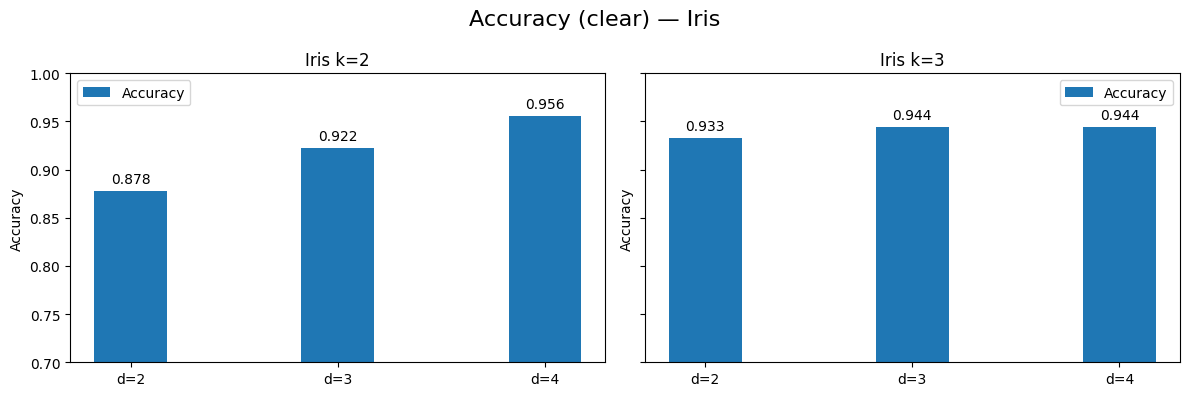

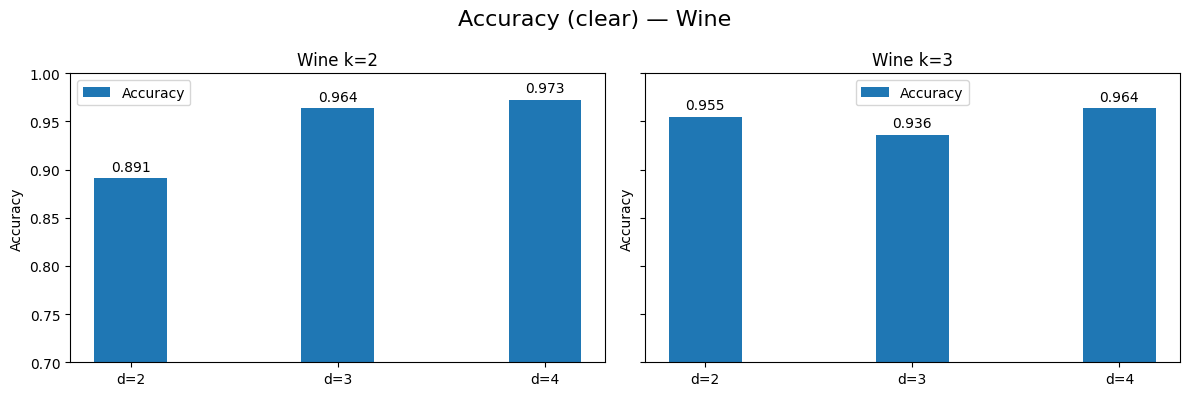

In [11]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt

base_dir = "/Users/sofianeazogagh/Desktop/PROBONITE/src/comp_free/gini_only"

datasets = ["iris", "wine"]
ks = [2, 3]
depths = [2, 3, 4]

# data[(dataset_name, k)][d] = mean_accuracy
data_gini_only = {}

for dataset_name in datasets:
    for k in ks:
        key = (dataset_name, k)
        data_gini_only[key] = {}
        for d in depths:
            log_path = os.path.join(
                base_dir,
                f"k={k}",
                f"d={d}",
                f"results_gini_only_{dataset_name}_k{k}_d{d}.txt",
            )

            if not os.path.isfile(log_path):
                print(f"[WARN] Fichier manquant : {log_path}")
                continue

            with open(log_path, "r") as f:
                log = f.read()

            # On ne cherche plus que "Accuracy:" dans les logs
            acc_list = [float(x) for x in re.findall(r"Accuracy:\s*([0-9.]+)", log)]

            if len(acc_list) == 0:
                raise RuntimeError(
                    f"Problème de parsing pour {dataset_name}, k={k}, d={d} : "
                    f"aucune valeur d'accuracy trouvée."
                )

            mean_acc = sum(acc_list) / len(acc_list)

            print(f"{dataset_name} k={k} d={d} -> Moyenne accuracy: {mean_acc:.4f}")

            data_gini_only[key][d] = mean_acc

# -----------------------------
# Plotting comme avant
# -----------------------------

for dataset_name in datasets:
    # on prépare les titres "Iris k=2", "Iris k=3", etc.
    subset_keys = [(dataset_name, k) for k in ks]

    fig, axes = plt.subplots(1, len(subset_keys), figsize=(8 + 4 * (len(subset_keys) - 1), 4), sharey=True)
    fig.suptitle(f"Accuracy (clear) — {dataset_name.capitalize()}", fontsize=16)

    if len(subset_keys) == 1:
        axes = [axes]

    for ax, (ds, k) in zip(axes, subset_keys):
        values = data_gini_only.get((ds, k), {})
        if not values:
            ax.set_title(f"{ds} k={k} (aucune donnée)")
            continue

        ds_depths = sorted(values.keys())
        accuracies = [values[d] for d in ds_depths]

        x = np.arange(len(ds_depths))
        width = 0.35

        ax.bar(x, accuracies, width, label="Accuracy")
        ax.set_title(f"{ds.capitalize()} k={k}")
        ax.set_xticks(x)
        ax.set_xticklabels([f"d={d}" for d in ds_depths])
        ax.set_ylim(0.7, 1.0)
        ax.set_ylabel("Accuracy")

        # Afficher les valeurs au-dessus des barres
        for i, v in enumerate(accuracies):
            ax.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

        ax.legend()

    plt.tight_layout()
    # Optionnel : sauvegarde
    plt.savefig(f"accuracy_gini_{dataset_name}.png", dpi=300)
    plt.show()

[HE] iris k=2 d=2 -> Moy D_0: 0.8444, Moy D_0+D_1: 0.8556
[HE] iris k=2 d=3 -> Moy D_0: 0.8667, Moy D_0+D_1: 0.8556
[HE] iris k=2 d=4 -> Moy D_0: 0.9444, Moy D_0+D_1: 0.9556
[HE] iris k=3 d=2 -> Moy D_0: 0.9333, Moy D_0+D_1: 0.9778
[HE] iris k=3 d=3 -> Moy D_0: 0.8778, Moy D_0+D_1: 0.9222
[HE] iris k=3 d=4 -> Moy D_0: 0.9444, Moy D_0+D_1: 0.9667
[HE] wine k=2 d=2 -> Moy D_0: 0.7909, Moy D_0+D_1: 0.9545
[HE] wine k=2 d=3 -> Moy D_0: 0.9455, Moy D_0+D_1: 0.9545
[HE] wine k=2 d=4 -> Moy D_0: 0.9636, Moy D_0+D_1: 0.9818
[HE] wine k=3 d=2 -> Moy D_0: 0.8545, Moy D_0+D_1: 0.9364
[HE] wine k=3 d=3 -> Moy D_0: 0.9545, Moy D_0+D_1: 0.9727
[HE] wine k=3 d=4 -> Moy D_0: 0.9455, Moy D_0+D_1: 0.9364
[CLEAR] iris k=2 d=2 -> Moy accuracy: 0.8778
[CLEAR] iris k=2 d=3 -> Moy accuracy: 0.9222
[CLEAR] iris k=2 d=4 -> Moy accuracy: 0.9556
[CLEAR] iris k=3 d=2 -> Moy accuracy: 0.9333
[CLEAR] iris k=3 d=3 -> Moy accuracy: 0.9444
[CLEAR] iris k=3 d=4 -> Moy accuracy: 0.9444
[CLEAR] wine k=2 d=2 -> Moy accura

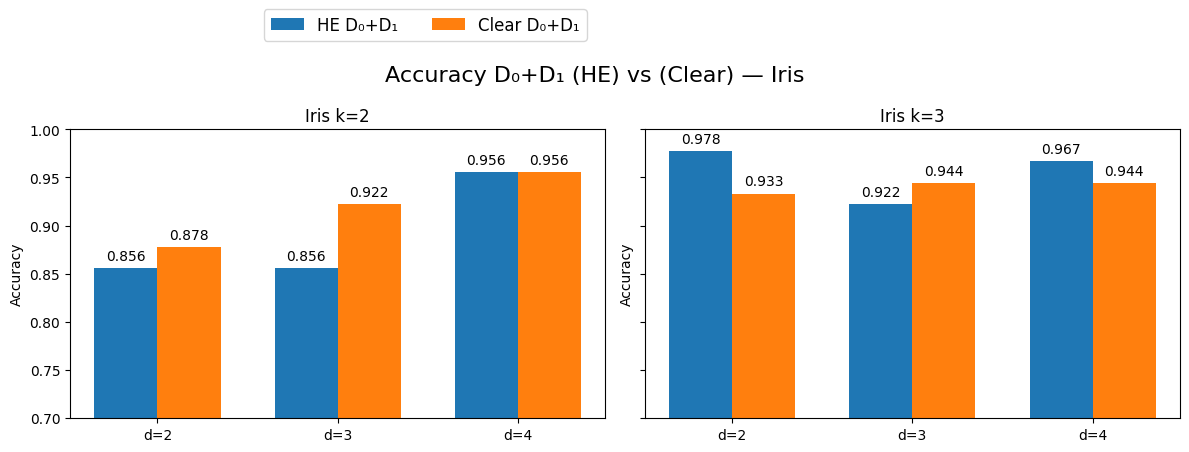

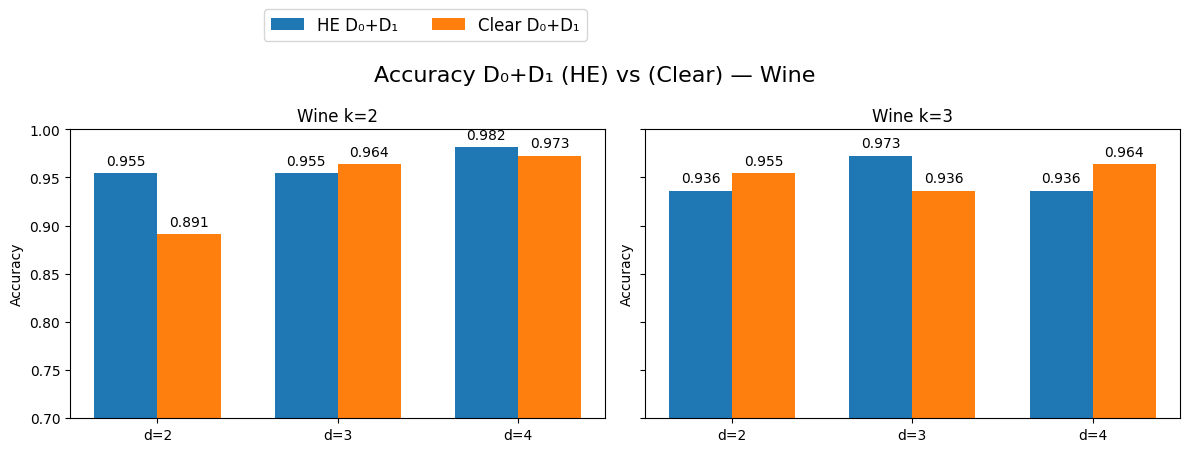

In [19]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------- Paramètres généraux ----------

datasets = ["iris", "wine"]
ks = [2, 3]
depths = [2, 3, 4]

base_dir_he = "/Users/sofianeazogagh/Desktop/PROBONITE/src/comp_free/no_clean"
base_dir_clear = "/Users/sofianeazogagh/Desktop/PROBONITE/src/comp_free/gini_only"

# data_he[(dataset_name, k)][d] = (mean_d0, mean_d1)
data_he = {}

# data_clear[(dataset_name, k)][d] = mean_accuracy
data_clear = {}

# ---------- Lecture des logs homomorphes (acc_d0, acc_d1) ----------

for dataset_name in datasets:
    for k in ks:
        key = (dataset_name, k)
        data_he.setdefault(key, {})
        for d in depths:
            log_path = os.path.join(
                base_dir_he,
                f"k={k}",
                f"d={d}",
                f"results_gini_{dataset_name}.txt",
            )

            if not os.path.isfile(log_path):
                print(f"[WARN] Fichier HE manquant : {log_path}")
                continue

            with open(log_path, "r") as f:
                log = f.read()

            acc_d0_list = [float(x) for x in re.findall(r"Accuracy on d_0:\s*([0-9.]+)", log)]
            acc_d1_list = [float(x) for x in re.findall(r"Accuracy on d_1:\s*([0-9.]+)", log)]

            if len(acc_d0_list) == 0 or len(acc_d0_list) != len(acc_d1_list):
                raise RuntimeError(
                    f"Problème de parsing HE pour {dataset_name}, k={k}, d={d} : "
                    f"{len(acc_d0_list)} valeurs d0, {len(acc_d1_list)} valeurs d1."
                )

            mean_d0 = sum(acc_d0_list) / len(acc_d0_list)
            mean_d1 = sum(acc_d1_list) / len(acc_d1_list)

            print(f"[HE] {dataset_name} k={k} d={d} -> "
                  f"Moy D_0: {mean_d0:.4f}, Moy D_0+D_1: {mean_d1:.4f}")

            data_he[key][d] = (mean_d0, mean_d1)

# ---------- Lecture des logs Gini-only (clair) ----------

for dataset_name in datasets:
    for k in ks:
        key = (dataset_name, k)
        data_clear.setdefault(key, {})
        for d in depths:
            log_path = os.path.join(
                base_dir_clear,
                f"k={k}",
                f"d={d}",
                f"results_gini_only_{dataset_name}_k{k}_d{d}.txt",
            )

            if not os.path.isfile(log_path):
                print(f"[WARN] Fichier CLEAR manquant : {log_path}")
                continue

            with open(log_path, "r") as f:
                log = f.read()

            acc_list = [float(x) for x in re.findall(r"Accuracy:\s*([0-9.]+)", log)]

            if len(acc_list) == 0:
                raise RuntimeError(
                    f"Problème de parsing CLEAR pour {dataset_name}, k={k}, d={d} : "
                    f"aucune valeur d'accuracy trouvée."
                )

            mean_acc = sum(acc_list) / len(acc_list)

            print(f"[CLEAR] {dataset_name} k={k} d={d} -> Moy accuracy: {mean_acc:.4f}")

            data_clear[key][d] = mean_acc

# ---------- Plot comparatif acc_d1 (HE) vs Gini-only (clair) ----------

legend_patches = None  # Pour récupérer les entrées de légende (une seule fois)

for dataset_name in datasets:
    subset_keys = [(dataset_name, k) for k in ks]

    fig, axes = plt.subplots(
        1,
        len(subset_keys),
        figsize=(8 + 4 * (len(subset_keys) - 1), 4),
        sharey=True,
    )
    fig.suptitle(
        f"Accuracy D₀+D₁ (HE) vs (Clear) — {dataset_name.capitalize()}",
        fontsize=16,
    )

    if len(subset_keys) == 1:
        axes = [axes]

    for ax, (ds, k) in zip(axes, subset_keys):
        values_he = data_he.get((ds, k), {})
        values_clear = data_clear.get((ds, k), {})

        # On ne garde que les profondeurs présentes dans les deux jeux de données
        common_depths = sorted(set(values_he.keys()) & set(values_clear.keys()))

        if not common_depths:
            ax.set_title(f"{ds} k={k} (aucune donnée commune)")
            continue

        acc_d1 = [values_he[d][1] for d in common_depths]
        acc_gini = [values_clear[d] for d in common_depths]

        x = np.arange(len(common_depths))
        width = 0.35

        rects1 = ax.bar(x - width/2, acc_d1, width, label="HE D₀+D₁")
        rects2 = ax.bar(x + width/2, acc_gini, width, label="Clear D₀+D₁")

        # On stocke les handles/labels de la légende la première fois
        if legend_patches is None:
            handles, labels = ax.get_legend_handles_labels()
            legend_patches = (handles, labels)
        ax.set_title(f"{ds.capitalize()} k={k}")
        ax.set_xticks(x)
        ax.set_xticklabels([f"d={d}" for d in common_depths])
        ax.set_ylim(0.7, 1.0)
        ax.set_ylabel("Accuracy")

        # Afficher les valeurs au-dessus des barres
        for i, v in enumerate(acc_d1):
            ax.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom")
        for i, v in enumerate(acc_gini):
            ax.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom")

        # On enlève la légende de chaque subplot
        ax.legend_.remove() if ax.get_legend() else None

    # Légende globale hors du graphe
    if legend_patches is not None:
        handles, labels = legend_patches
        fig.legend(handles, labels, loc='right', ncol=2, bbox_to_anchor=(0.5, 1.08), fontsize=12)

    plt.tight_layout()
    plt.savefig(f"accuracy_D1_vs_gini_only_{dataset_name}.png", dpi=300, bbox_inches='tight')
    plt.show()